In [1]:
import itertools as it

import boto3
import botocore
from cliffs_delta import cliffs_delta
from IPython.core.display import display, HTML
from matplotlib import pyplot as plt
from matplotlib import ticker as mpl_ticker
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmyxb0g
interpreter: 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
notebook name: 2025-11-25-external-selfbb-timeshift
notebook path: /home/runner/work/oee4/oee4/binder/2025-11-25-external-selfbb-timeshift.ipynb
revision: bdac574
timestamp: 2026-05-24T01:09:42Z00:00

IPython==7.16.1
packaging==26.0


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2025-11-25-external-timeshift"


In [5]:
df_all = []
for what, prefix in [
    ("nobb", "endeavor=16/external-competitions/stage=2+what=collated/"),
    ("selfbb", "endeavor=16/external-competitions-focalbb/stage=2+what=collated/"),
    ("selfbb33", "endeavor=16/external-competitions-bg33-focalbb/stage=2+what=collated/"),
    ("selfbb40", "endeavor=16/external-competitions-bg40-focalbb/stage=2+what=collated/"),
    ("selfbb50", "endeavor=16/external-competitions-bg50-focalbb/stage=2+what=collated/"),
    ("selfbb66", "endeavor=16/external-competitions-bg66-focalbb/stage=2+what=collated/"),
    ("selfbb75", "endeavor=16/external-competitions-bg75-focalbb/stage=2+what=collated/"),
    ("truebb", "endeavor=16/external-competitions-focalbb-true/stage=2+what=collated/"),
    ("selfbb90", "endeavor=16/external-competitions-bg90-focalbb/stage=2+what=collated/"),
    ("selfbb99", "endeavor=16/external-competitions-bg99-focalbb/stage=2+what=collated/"),
]:
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket("prq49")


    competitions = bucket_handle.objects.filter(Prefix=prefix)
    dfs = [
        pd.read_csv(
          f's3://prq49/{competitions.key}',
        )
        for competitions in competitions
    ]
    print(len(dfs))
    df = pd.concat(dfs, ignore_index=True)
    df["kind"] = what

    df_all.append(df)

df = pd.concat(df_all, ignore_index=True)


100
100
20
20
20
20
20
99
20
20


0         1.000000
2         0.247078
4         0.006954
6         0.393959
8         0.299972
            ...   
354612    0.000000
354615    0.000000
354618    0.929577
354620    0.147200
354623    1.000000
Name: Focal Prevalence, Length: 131222, dtype: float64

teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


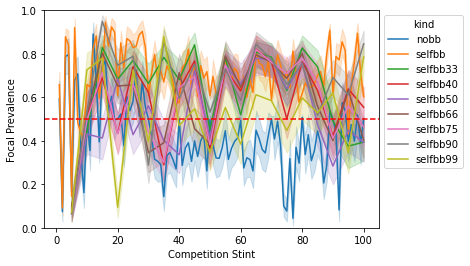

In [6]:
dfx = df.loc[
    (df["Root ID"] == 0),
    ["Competition Stint", "Focal Prevalence", "kind"]
]
display(dfx["Focal Prevalence"])

with tp.teed(
    sns.lineplot,
    data=dfx[
        dfx["kind"] != "truebb"
    ],
    x="Competition Stint",
    y="Focal Prevalence",
    hue="kind",
    teeplot_subdir=teeplot_subdir,
) as ax:
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

    plt.axhline(y=0.5, color='r', linestyle='--')
    plt.ylim(0, 1)


,Competition Stint,kind,Focal Prevalence
0,1,selfbb,0.065354
1,2,selfbb,0.017319
2,2,truebb,-0.044790
3,3,selfbb,0.090830
4,3,truebb,0.043589
...,...,...,...
334,100,selfbb66,-0.094725
335,100,selfbb75,-0.034438
336,100,selfbb90,0.347460
337,100,selfbb99,0.287041


<ipython-input-7-a4e3f1512c68>:77: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(
<ipython-input-7-a4e3f1512c68>:77: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(
<ipython-input-7-a4e3f1512c68>:77: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(
<ipython-input-7-a4e3f1512c68>:77: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(
<ipython-input-7-a4e3f1512c68>:77: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(
<ipython-input-7-a4e3f1512c68>:77: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(
<ipython-input-7-a4e3f1512c68>:77: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(
<ipython-input-7-a4e3f1512c68>:77: UserWarning: Ignoring `palette` be

teeplots/2025-11-25-external-timeshift/viz=figure+ext=.pdf
teeplots/2025-11-25-external-timeshift/viz=figure+ext=.png


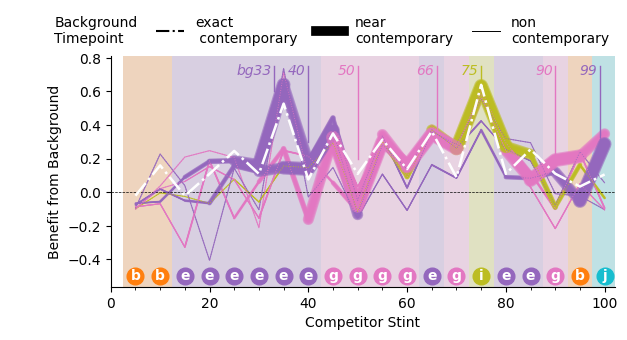

In [7]:
dfx = df.loc[
    (df["Root ID"] == 0),
    ["Competition Stint", "Focal Prevalence", "kind"]
].groupby(["Competition Stint", "kind"]).mean()

# 2. Unstack 'kind' to move it to columns
# This creates a wide table where every 'kind' is a separate column
df_wide = dfx.unstack("kind")

# 3. Isolate the 'selfbb' values
# Note: df_wide has MultiIndex columns: ('Focal Prevalence', 'selfbb')
nobb_vals = df_wide[("Focal Prevalence", "nobb")]

# 4. Subtract 'nobb' from all columns
# axis=0 ensures we align by 'Competition Stint'
df_diff = df_wide.sub(nobb_vals, axis=0)

# 5. Drop 'nobb' and Stack back to rows
# We drop the nobb column because the result is 0 and you requested it be removed
final_df = df_diff.drop(
    columns=[("Focal Prevalence", "nobb")]
).stack("kind").reset_index(drop=False)

display(final_df)

final_df = final_df[
    (final_df["Competition Stint"] % 5 == 0)
    # & (final_df["Competition Stint"] < 100)
    # | (final_df["Competition Stint"].isin([99]))
    # | (final_df["Competition Stint"].isin([33, 66, 99]))
]

with tp.teed(
    plt.figure,
    figsize=(6.5, 3),
    teeplot_subdir=teeplot_subdir,
) as fig:

    for size, dfs in [
        (2.75, final_df[final_df["kind"] == "selfbb"]),
        (1, final_df[~final_df["kind"].isin(["selfbb", "truebb"])]),
        *(
            (
                size,
                final_df[
                    (final_df["kind"] == f"selfbb{bb}")
                    & (np.abs(final_df["Competition Stint"] - bb) <= dxs)
                ]
            )
            for size, dxs in [
                (1.2, 101),
                (1.2, 51),
                (1.2, 46),
                (2, 36),
                (3, 26),
                (4, 21),
                (5, 21),
                (6, 16),
                (8, 11),
                (10, 11),
                (12, 11),
                (10, 6),
                # (11, 6),
                (12, 6),
                (13, 6),
                # (14, 6),
                (15, 6),
            ]
            for bb in [*range(5, 100, 5), 33, 66, 99]
        ),
    ]:
        alpha = 0.9
        if size > 2:
            alpha = 0.6
        if size == 2.75:
            alpha = 0.99
        ax = sns.lineplot(
            data=dfs.reset_index(),
            x="Competition Stint",
            y="Focal Prevalence",
            hue="kind",
            legend=False,
            lw=size / 1.5,
            ls=("-" if size != 2.75 else "-.") if size != 1 else ":",
            solid_capstyle="round",
            palette={
                "selfbb": "white",
                "selfbb33": sns.color_palette("tab10")[4],
                "selfbb40": sns.color_palette("tab10")[4],
                "selfbb50": sns.color_palette("tab10")[6],
                "selfbb66": sns.color_palette("tab10")[6],
                "selfbb75": sns.color_palette("tab10")[8],
                "selfbb90": sns.color_palette("tab10")[6],
                "selfbb99": sns.color_palette("tab10")[4],
            },
            alpha=alpha,
            zorder=((None if size != 2.75 else 1000) if size != 1 else 100),
        )

    ax.axhline(y=0, color="k", linestyle='--', lw=0.5)

    for x, (m, color) in enumerate(
        [
            (x,
            sns.color_palette("tab10")[
                {
                    "a": 0,
                    "b": 1,
                    "c": 2,
                    "d": 3,
                    "e": 4,
                    "f": 5,
                    "g": 6,
                    "h": 7,
                    "i": 8,
                    "j": 9,
                }[x]
            ])
            for x in [
                "a", "b", "c", "b", "b", "b", "b", "b", "b", "b",  # 0
                "b", "b", "b", "b", "d", "e", "e", "e", "e", "e",  # 10
                "e", "e", "e", "e", "e", "e", "b", "e", "b", "e",  # 20
                "e", "e", "e", "e", "e", "e", "e", "e", "e", "f",  # 30
                "e", "e", "e", "e", "e", "g", "g", "g", "g", "g",  # 40
                "g", "g", "g", "e", "g", "g", "g", "g", "g", "h",  # 50
                "g", "e", "g", "g", "e", "e", "g", "g", "e", "g",  # 60
                "g", "g", "g", "e", "i", "i", "g", "g", "e", "g",  # 70
                "e", "e", "e", "e", "e", "e", "e", "e", "e", "g",  # 80
                "g", "e", "i", "e", "e", "b", "b", "h", "e", "e",  # 90
                "j",  # 100
            ]
        ],
    ):
        # ax.axvspan(x + 0.5, x + 1.5, alpha=0.2, color=color, lw=0)
        while "breakable":
            if x != 0 and x % 5 == 0:
                ax.axvspan(x - 2.5, x + 2.5, alpha=0.2, color=color, lw=0)
            # elif x == 99:
            #     ax.axvspan(x - 1.5, x + 2.5, alpha=0.2, color=color, lw=0)
            else:
                break

            ax.plot(
                [x],
                [-0.5],
                marker=".",
                ms=24,
                color=color
            )
            ax.text(
                x=x,
                y=-0.5,
                s=m,
                color="white",
                ha="center",
                va="center",
                fontweight="bold",
            )
            break

        # elif x == 33:
        #     ax.axvspan(x - 0.5, x + 1.5, alpha=0.2, color=color, lw=0)
        # elif x == 66:
        #     ax.axvspan(x - 0.5, x + 1.5, alpha=0.2, color=color, lw=0)

    ax.set_xlabel("Competitor Stint")
    ax.set_ylabel("Benefit from Background")
    sns.despine(ax=ax)
    plt.axvspan(2.5, 102.5, color="gainsboro", alpha=0.6, zorder=-1, lw=0)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color="none", label="Background\nTimepoint"),
        Line2D([0], [0], color="black", linestyle="-.", label="exact\n contemporary"),
        Line2D([0], [0], color="black", linewidth=7, linestyle="-", label="near\ncontemporary"),
        Line2D([0], [0], color="black", linewidth=0.7, linestyle="-", label="non\ncontemporary")
    ]

    ax.legend(
        handles=legend_elements,
        loc="lower left", # Anchor point for the legend box
        bbox_to_anchor=(-0.2, 1.02, 1.2, 0.2), # (x, y, width, height)
        mode="expand",
        borderaxespad=0,
        ncol=4,
        frameon=False,
    )
    ax.set_xlim(0, 102)
    # ax.add_artist(top_legend)

    ax.plot(
        [33, 33],
        [0.6, 0.75],
        color=sns.color_palette("tab10")[4],
        lw=1,
    )
    ax.text(
        x=32.5,
        y=0.72,
        s="bg33",
        color=sns.color_palette("tab10")[4],
        ha="right",
        va="center",
        fontstyle="italic",
    )

    ax.plot(
        [40, 40],
        [0.3, 0.75],
        color=sns.color_palette("tab10")[4],
        lw=1,
    )
    ax.text(
        x=39.5,
        y=0.72,
        s="40",
        color=sns.color_palette("tab10")[4],
        ha="right",
        va="center",
        fontstyle="italic",
    )

    ax.plot(
        [50, 50],
        [0.2, 0.75],
        color=sns.color_palette("tab10")[6],
        lw=1,
    )
    ax.text(
        x=49.5,
        y=0.72,
        s="50",
        color=sns.color_palette("tab10")[6],
        ha="right",
        va="center",
        fontstyle="italic",
    )

    ax.plot(
        [66, 66],
        [0.3, 0.75],
        color=sns.color_palette("tab10")[6],
        lw=1,
    )
    ax.text(
        x=65.5,
        y=0.72,
        s="66",
        color=sns.color_palette("tab10")[6],
        ha="right",
        va="center",
        fontstyle="italic",
    )

    ax.plot(
        [75, 75],
        [0.65, 0.75],
        color=sns.color_palette("tab10")[8],
        lw=1,
    )
    ax.text(
        x=74.5,
        y=0.72,
        s="75",
        color=sns.color_palette("tab10")[8],
        ha="right",
        va="center",
        fontstyle="italic",
    )

    ax.plot(
        [90, 90],
        [0.2, 0.75],
        color=sns.color_palette("tab10")[6],
        lw=1,
    )
    ax.text(
        x=89.5,
        y=0.72,
        s="90",
        color=sns.color_palette("tab10")[6],
        ha="right",
        va="center",
        fontstyle="italic",
    )

    ax.plot(
        [99, 99],
        [0.2, 0.75],
        color=sns.color_palette("tab10")[4],
        lw=1,
    )
    ax.text(
        x=98.5,
        y=0.72,
        s="99",
        color=sns.color_palette("tab10")[4],
        ha="right",
        va="center",
        fontstyle="italic",
    )
    ax.xaxis.set_minor_locator(mpl_ticker.MultipleLocator(5))

    # from matplotlib.patches import Patch
    # ax.legend(
    #     handles=[
    #     Patch(facecolor=sns.color_palette("tab10")[i], label=label)
    #     for i, label in enumerate("abcdefghi")
    #     if label not in "acdfh"
    # ],
    #     title="Morph",
    #     loc='upper left',
    #     bbox_to_anchor=(1.02, 1), # Place it just to the right of the axes
    #     borderaxespad=0,
    #     frameon=False # Optional: Remove border
    # )


,Competition Stint,kind,Focal Prevalence
0,1,selfbb,0.065354
1,2,selfbb,0.017319
2,2,truebb,-0.044790
3,3,selfbb,0.090830
4,3,truebb,0.043589
...,...,...,...
334,100,selfbb66,-0.094725
335,100,selfbb75,-0.034438
336,100,selfbb90,0.347460
337,100,selfbb99,0.287041


teeplots/2025-11-25-external-timeshift/viz=subplots+ext=.pdf
teeplots/2025-11-25-external-timeshift/viz=subplots+ext=.png


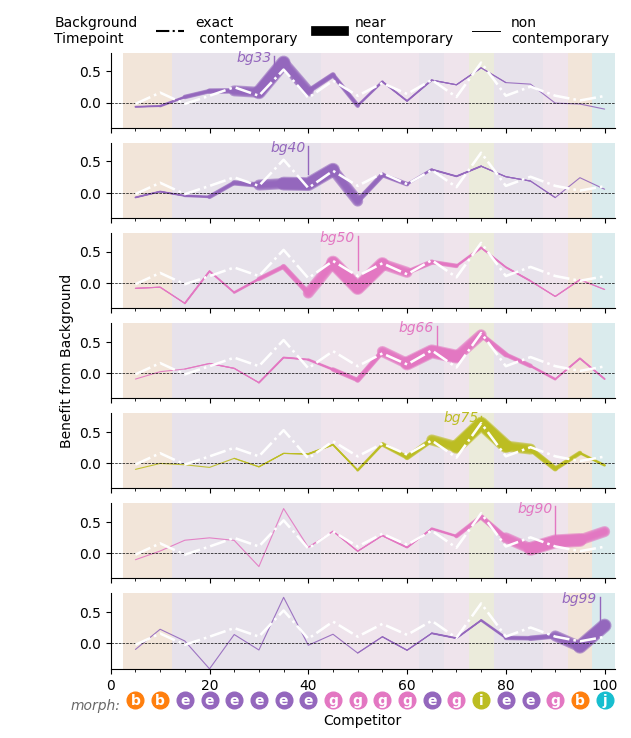

In [8]:
dfx = df.loc[
    (df["Root ID"] == 0),
    ["Competition Stint", "Focal Prevalence", "kind"]
].groupby(["Competition Stint", "kind"]).mean()

# 2. Unstack 'kind' to move it to columns
# This creates a wide table where every 'kind' is a separate column
df_wide = dfx.unstack("kind")

# 3. Isolate the 'selfbb' values
# Note: df_wide has MultiIndex columns: ('Focal Prevalence', 'selfbb')
nobb_vals = df_wide[("Focal Prevalence", "nobb")]

# 4. Subtract 'nobb' from all columns
# axis=0 ensures we align by 'Competition Stint'
df_diff = df_wide.sub(nobb_vals, axis=0)

# 5. Drop 'nobb' and Stack back to rows
# We drop the nobb column because the result is 0 and you requested it be removed
final_df = df_diff.drop(
    columns=[("Focal Prevalence", "nobb")]
).stack("kind").reset_index(drop=False)

display(final_df)

final_df = final_df[
    (final_df["Competition Stint"] % 5 == 0)
    # & (final_df["Competition Stint"] < 100)
    # | (final_df["Competition Stint"].isin([99]))
    # | (final_df["Competition Stint"].isin([33, 66, 99]))
]

with tp.teed(
    plt.subplots,
    figsize=(6.5, 8),
    nrows=7,
    teeplot_subdir=teeplot_subdir,
    sharex=True,
    sharey=True,
) as teed:

    fig,  (ax1, ax2, ax3, ax4, ax5, ax6, ax7) = teed
    axes = {
        "selfbb33": [ax1],
        "selfbb40": [ax2],
        "selfbb50": [ax3],
        "selfbb66": [ax4],
        "selfbb75": [ax5],
        "selfbb90": [ax6],
        "selfbb99": [ax7],
        "selfbb": [ax1, ax2, ax3, ax4, ax5, ax6, ax7],
    }

    for size, dfs in [
        (2.75, final_df[final_df["kind"] == "selfbb"]),
        # (1, final_df[~final_df["kind"].isin(["selfbb", "truebb"])]),
        *(
            (
                size,
                final_df[
                    (final_df["kind"] == f"selfbb{bb}")
                    & (np.abs(final_df["Competition Stint"] - bb) <= dxs)
                ]
            )
            for size, dxs in [
                (1.2, 101),
                (1.2, 51),
                (1.2, 46),
                (2, 36),
                (3, 26),
                (4, 21),
                (5, 21),
                (6, 16),
                (8, 11),
                (10, 11),
                (12, 11),
                (10, 6),
                # (11, 6),
                (12, 6),
                (13, 6),
                # (14, 6),
                (15, 6),
            ]
            for bb in [*range(5, 100, 5), 33, 66, 99]
        ),
    ]:
        try:
            kind, = dfs["kind"].unique()
        except ValueError:
            continue
        axs = axes[kind]
        alpha = 0.9
        if size > 2:
            alpha = 0.6
        if size == 2.75:
            alpha = 0.99
        for ax in axs:
            sns.lineplot(
                data=dfs.reset_index(),
                x="Competition Stint",
                y="Focal Prevalence",
                ax=ax,
                hue="kind",
                legend=False,
                lw=size / 1.5,
                ls=("-" if size != 2.75 else "-.") if size != 1 else ":",
                solid_capstyle="round",
                palette={
                    "selfbb": "white",
                    "selfbb33": sns.color_palette("tab10")[4],
                    "selfbb40": sns.color_palette("tab10")[4],
                    "selfbb50": sns.color_palette("tab10")[6],
                    "selfbb66": sns.color_palette("tab10")[6],
                    "selfbb75": sns.color_palette("tab10")[8],
                    "selfbb90": sns.color_palette("tab10")[6],
                    "selfbb99": sns.color_palette("tab10")[4],
                },
                alpha=alpha,
                zorder=((None if size != 2.75 else 1000) if size != 1 else 100),
            )

    for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7]:
        ax.axhline(y=0, color="k", linestyle='--', lw=0.5)

        for x, (m, color) in enumerate(
            [
                (x,
                sns.color_palette("tab10")[
                    {
                        "a": 0,
                        "b": 1,
                        "c": 2,
                        "d": 3,
                        "e": 4,
                        "f": 5,
                        "g": 6,
                        "h": 7,
                        "i": 8,
                        "j": 9,
                    }[x]
                ])
                for x in [
                    "a", "b", "c", "b", "b", "b", "b", "b", "b", "b",  # 0
                    "b", "b", "b", "b", "d", "e", "e", "e", "e", "e",  # 10
                    "e", "e", "e", "e", "e", "e", "b", "e", "b", "e",  # 20
                    "e", "e", "e", "e", "e", "e", "e", "e", "e", "f",  # 30
                    "e", "e", "e", "e", "e", "g", "g", "g", "g", "g",  # 40
                    "g", "g", "g", "e", "g", "g", "g", "g", "g", "h",  # 50
                    "g", "e", "g", "g", "e", "e", "g", "g", "e", "g",  # 60
                    "g", "g", "g", "e", "i", "i", "g", "g", "e", "g",  # 70
                    "e", "e", "e", "e", "e", "e", "e", "e", "e", "g",  # 80
                    "g", "e", "i", "e", "e", "b", "b", "h", "e", "e",  # 90
                    "j",  # 100
                ]
            ],
        ):
            # ax.axvspan(x + 0.5, x + 1.5, alpha=0.2, color=color, lw=0)
            while "breakable":
                if x != 0 and x % 5 == 0:
                    ax.axvspan(x - 2.5, x + 2.5, alpha=0.1, color=color, lw=0)
                # elif x == 99:
                #     ax.axvspan(x - 1.5, x + 2.5, alpha=0.2, color=color, lw=0)
                else:
                    break

                if ax is ax7:
                    ax.plot(
                        [x],
                        [-0.91],
                        marker=".",
                        ms=24,
                        color=color,
                        clip_on=False,
                    )
                    ax.text(
                        x=x,
                        y=-0.91,
                        s=m,
                        color="white",
                        ha="center",
                        va="center",
                        fontweight="bold",
                        clip_on=False,
                    )
                break

            # elif x == 33:
            #     ax.axvspan(x - 0.5, x + 1.5, alpha=0.2, color=color, lw=0)
            # elif x == 66:
            #     ax.axvspan(x - 0.5, x + 1.5, alpha=0.2, color=color, lw=0)

        ax.set_xlim(0, 102)
        ax.set_xlabel("\nCompetitor")
        if ax is ax4:
            ax.set_ylabel("Benefit from Background")
        else:
            ax.set_ylabel("")
        sns.despine(ax=ax)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color="none", label="Background\nTimepoint"),
        Line2D([0], [0], color="black", linestyle="-.", label="exact\n contemporary"),
        Line2D([0], [0], color="black", linewidth=7, linestyle="-", label="near\ncontemporary"),
        Line2D([0], [0], color="black", linewidth=0.7, linestyle="-", label="non\ncontemporary")
    ]

    ax1.legend(
        handles=legend_elements,
        loc="lower left", # Anchor point for the legend box
        bbox_to_anchor=(-0.2, 1.02, 1.2, 0.2), # (x, y, width, height)
        mode="expand",
        borderaxespad=0,
        ncol=4,
        frameon=False,
    )
    # ax.add_artist(top_legend)

    ax1.plot(
        [33, 33],
        [0.6, 0.75],
        color=sns.color_palette("tab10")[4],
        lw=1,
    )
    ax1.text(
        x=32.5,
        y=0.72,
        s="bg33",
        color=sns.color_palette("tab10")[4],
        ha="right",
        va="center",
        fontstyle="italic",
    )

    ax2.plot(
        [40, 40],
        [0.3, 0.75],
        color=sns.color_palette("tab10")[4],
        lw=1,
    )
    ax2.text(
        x=39.5,
        y=0.72,
        s="bg40",
        color=sns.color_palette("tab10")[4],
        ha="right",
        va="center",
        fontstyle="italic",
    )

    ax3.plot(
        [50, 50],
        [0.2, 0.75],
        color=sns.color_palette("tab10")[6],
        lw=1,
    )
    ax3.text(
        x=49.5,
        y=0.72,
        s="bg50",
        color=sns.color_palette("tab10")[6],
        ha="right",
        va="center",
        fontstyle="italic",
    )

    ax4.plot(
        [66, 66],
        [0.3, 0.75],
        color=sns.color_palette("tab10")[6],
        lw=1,
    )
    ax4.text(
        x=65.5,
        y=0.72,
        s="bg66",
        color=sns.color_palette("tab10")[6],
        ha="right",
        va="center",
        fontstyle="italic",
    )

    ax5.plot(
        [75, 75],
        [0.65, 0.75],
        color=sns.color_palette("tab10")[8],
        lw=1,
    )
    ax5.text(
        x=74.5,
        y=0.72,
        s="bg75",
        color=sns.color_palette("tab10")[8],
        ha="right",
        va="center",
        fontstyle="italic",
    )

    ax6.plot(
        [90, 90],
        [0.2, 0.75],
        color=sns.color_palette("tab10")[6],
        lw=1,
    )
    ax6.text(
        x=89.5,
        y=0.72,
        s="bg90",
        color=sns.color_palette("tab10")[6],
        ha="right",
        va="center",
        fontstyle="italic",
    )

    ax7.plot(
        [99, 99],
        [0.2, 0.75],
        color=sns.color_palette("tab10")[4],
        lw=1,
    )
    ax7.text(
        x=98.5,
        y=0.72,
        s="bg99",
        color=sns.color_palette("tab10")[4],
        ha="right",
        va="center",
        fontstyle="italic",
    )

    for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7]:
        ax.set_ylim(-0.4, 0.8)
        ax.axvspan(2.5, 102.5, color="gainsboro", alpha=0.4, zorder=-1, lw=0)
        ax.xaxis.set_minor_locator(mpl_ticker.MultipleLocator(5))

    ax7.text(
        x=2,
        y=-0.99,
        s="morph:",
        ha="right",
        va="center",
        color="dimgray",
        fontstyle="italic",
    )

    # from matplotlib.patches import Patch
    # ax.legend(
    #     handles=[
    #     Patch(facecolor=sns.color_palette("tab10")[i], label=label)
    #     for i, label in enumerate("abcdefghi")
    #     if label not in "acdfh"
    # ],
    #     title="Morph",
    #     loc='upper left',
    #     bbox_to_anchor=(1.02, 1), # Place it just to the right of the axes
    #     borderaxespad=0,
    #     frameon=False # Optional: Remove border
    # )


,Competition Stint,kind,Focal Prevalence
0,1,selfbb,0.065354
1,2,selfbb,0.017319
2,2,truebb,-0.044790
3,3,selfbb,0.090830
4,3,truebb,0.043589
...,...,...,...
334,100,selfbb66,-0.094725
335,100,selfbb75,-0.034438
336,100,selfbb90,0.347460
337,100,selfbb99,0.287041


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:227: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  teed = plotter(*args, **{k: v for k, v in kwargs.items()})
<ipython-input-9-ef7b391c5db6>:49: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(


teeplots/2025-11-25-external-timeshift/hue=isexact+orient=h+viz=swarmplot+x=focal-prevalence+y=isexact+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=isexact+orient=h+viz=swarmplot+x=focal-prevalence+y=isexact+ext=.png


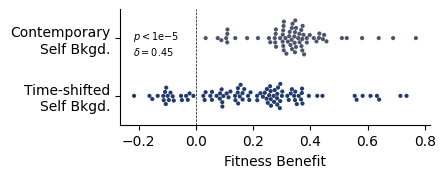

MannwhitneyuResult(statistic=4992.0, pvalue=5.0563343869678804e-08)

(0.49819927971188477, 'large')

KruskalResult(statistic=5.425921017757787, pvalue=0.4904549840278968)

,bg,statistic,pvalue
0,33,336.0,0.085592
1,40,234.0,0.002919
2,50,183.0,0.000313
3,66,213.0,0.001217
4,75,209.0,0.001023
5,90,332.0,0.076991
6,99,165.0,0.000130


In [9]:
dfx = df.loc[
    (df["Root ID"] == 0),
    ["Competition Stint", "Focal Prevalence", "kind"]
].groupby(["Competition Stint", "kind"]).mean()

# 2. Unstack 'kind' to move it to columns
# This creates a wide table where every 'kind' is a separate column
df_wide = dfx.unstack("kind")

# 3. Isolate the 'selfbb' values
# Note: df_wide has MultiIndex columns: ('Focal Prevalence', 'selfbb')
nobb_vals = df_wide[("Focal Prevalence", "nobb")]

# 4. Subtract 'nobb' from all columns
# axis=0 ensures we align by 'Competition Stint'
df_diff = df_wide.sub(nobb_vals, axis=0)

# 5. Drop 'nobb' and Stack back to rows
# We drop the nobb column because the result is 0 and you requested it be removed
final_df = df_diff.drop(
    columns=[("Focal Prevalence", "nobb")]
).stack("kind").reset_index(drop=False)

display(final_df)

final_df = final_df[
    (final_df["Competition Stint"] > 32)
    & (final_df["kind"] != "truebb")
]

final_df["isexact"] = final_df["kind"] == "selfbb"
with tp.teed(
    sns.swarmplot,
    data=final_df,
    y="isexact",
    x="Focal Prevalence",
    hue="isexact",
    legend=False,
    size=3,
    order=[True, False],
    orient="h",
    palette=sns.color_palette("cividis"),
    teeplot_outexclude=["palette"],
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.figure.set_size_inches(4, 1.5)
    ax.set_xlabel("Fitness Benefit")
    ax.set_ylabel(None)
    ax.set_yticklabels(
        ["Contemporary\nSelf Bkgd.", "Time-shifted\nSelf Bkgd."],
    )
    ax.axvline(x=0, color="k", linestyle='--', lw=0.5)
    sns.despine(ax=ax)
    ax.text(
        x=-0.22,
        y=0.3,
        s="$p < 1\mathrm{e}{-5}$\n$\delta=0.45$",
        fontsize=7,
    )

display(
    scipy_stats.mannwhitneyu(
        final_df.loc[final_df["isexact"], "Focal Prevalence"],
        final_df.loc[~final_df["isexact"], "Focal Prevalence"],
        alternative="two-sided",
    ),
)

display(
    cliffs_delta(
        final_df.loc[final_df["isexact"], "Focal Prevalence"],
        final_df.loc[~final_df["isexact"], "Focal Prevalence"],
    ),
)

display(HTML("<h1>screen between kinds</h1>"))

display(
    scipy_stats.kruskal(
        *[
            final_df.loc[final_df["kind"] == kind, "Focal Prevalence"]
            for kind in final_df["kind"].unique()
            if kind != "selfbb"
        ],
    ),
)

res = []
for bb in [33, 40, 50, 66, 75, 90, 99]:
    stat = scipy_stats.mannwhitneyu(
        final_df.loc[final_df["kind"] == f"selfbb{bb}", "Focal Prevalence"],
        final_df.loc[final_df["kind"] == "selfbb", "Focal Prevalence"],
        alternative="two-sided",
    )
    res.append(
        {
            "bg": bb,
            "statistic": stat.statistic,
            "pvalue": stat.pvalue,
        },
    )

display(pd.DataFrame(res))


Focal Prevalence
Competition Stint kind                      
1                 nobb              0.592569
                  selfbb            0.657924
2                 nobb              0.074193
                  selfbb            0.091512
                  truebb            0.029403
...                                      ...
100               selfbb66          0.403701
                  selfbb75          0.463988
                  selfbb90          0.845886
                  selfbb99          0.785467
                  truebb            0.517070

[439 rows x 1 columns]

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+type=legendsquare+viz=imshow+ext=.png


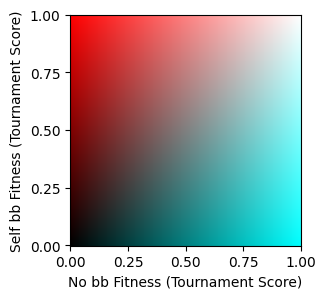

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+type=legendband+viz=imshow+ext=.png


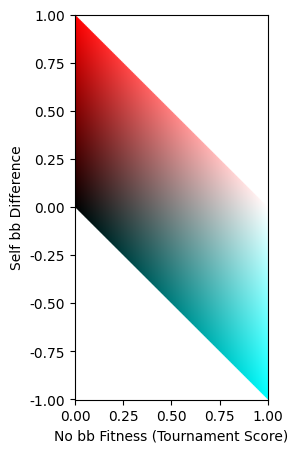

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+slice=all+type=square+viz=imshow+ext=.png


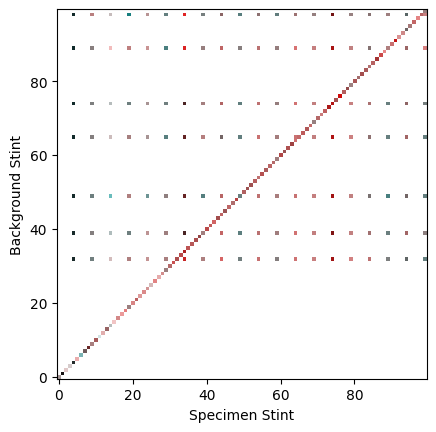

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+slice=sub+type=square+viz=imshow+ext=.png


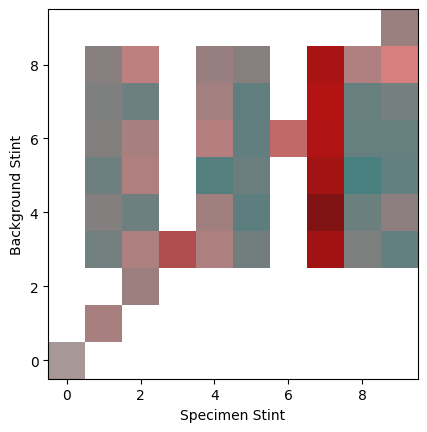

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+slice=all+type=band+viz=imshow+ext=.png


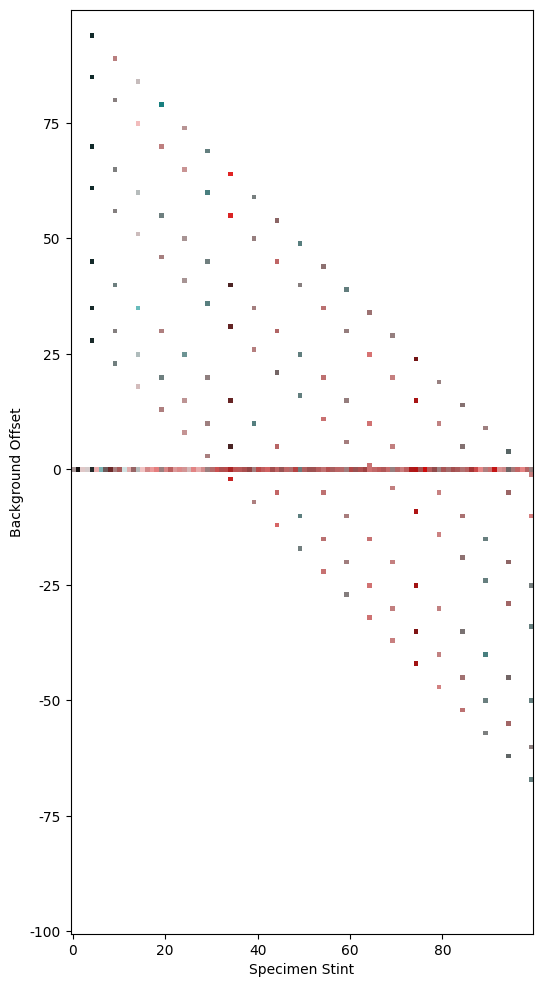

teeplots/2025-11-25-external-timeshift/palette=0+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=0+slice=sub+type=band+viz=imshow+ext=.png


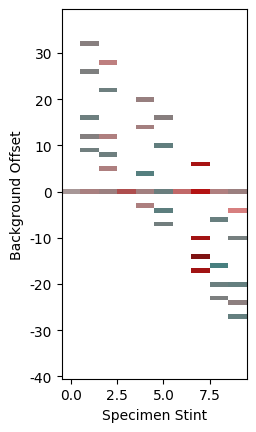

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+type=legendsquare+viz=imshow+ext=.png


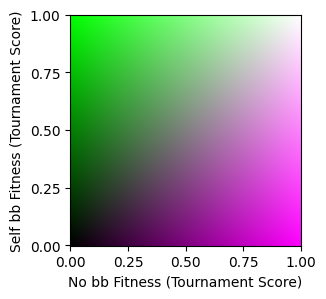

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+type=legendband+viz=imshow+ext=.png


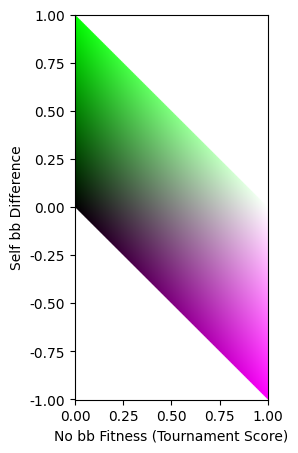

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+slice=all+type=square+viz=imshow+ext=.png


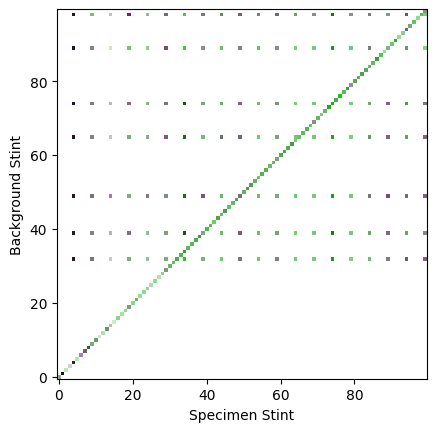

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+slice=sub+type=square+viz=imshow+ext=.png


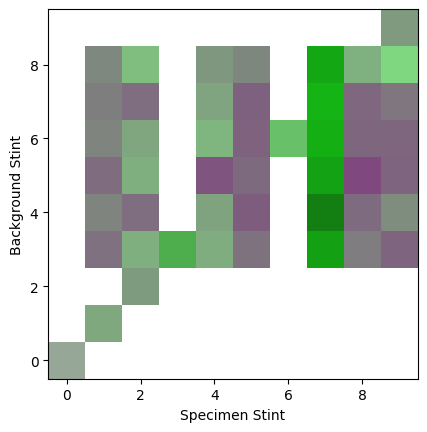

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+slice=all+type=band+viz=imshow+ext=.png


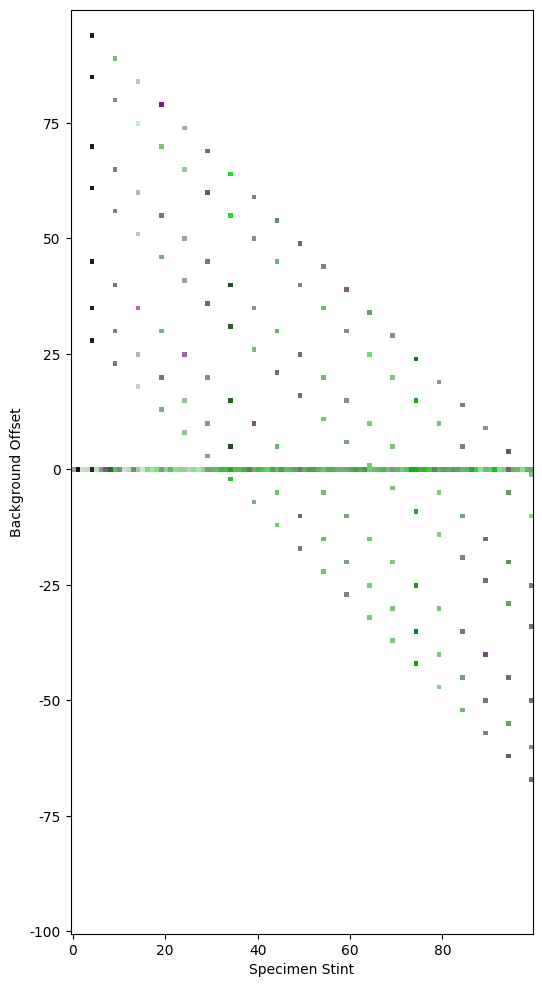

teeplots/2025-11-25-external-timeshift/palette=1+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=1+slice=sub+type=band+viz=imshow+ext=.png


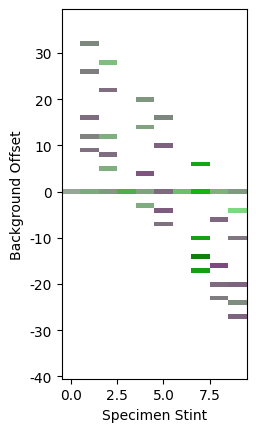

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+type=legendsquare+viz=imshow+ext=.png


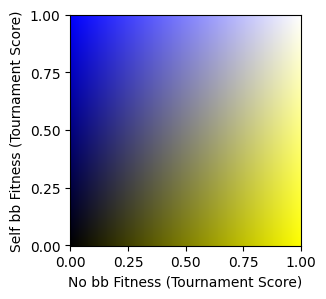

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+type=legendband+viz=imshow+ext=.png


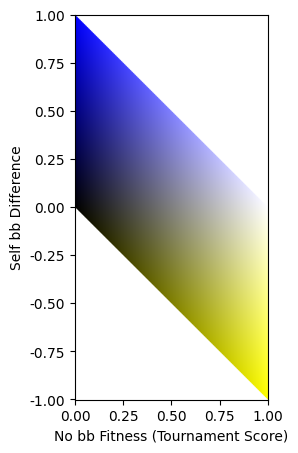

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+slice=all+type=square+viz=imshow+ext=.png


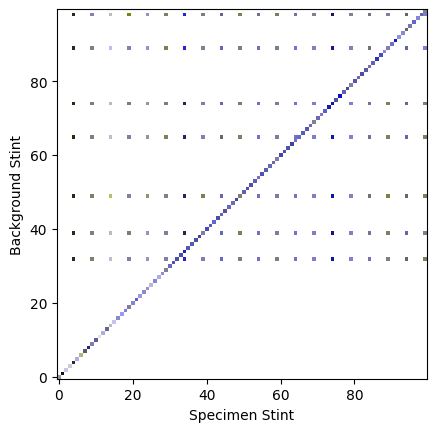

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+slice=sub+type=square+viz=imshow+ext=.png


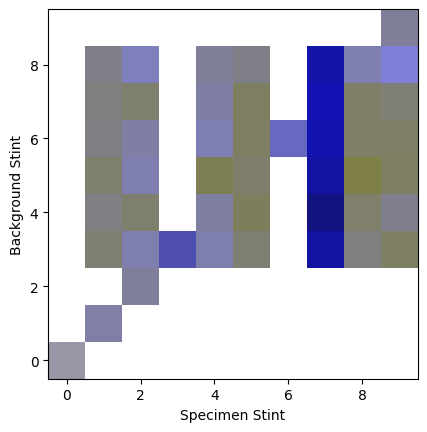

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+slice=all+type=band+viz=imshow+ext=.png


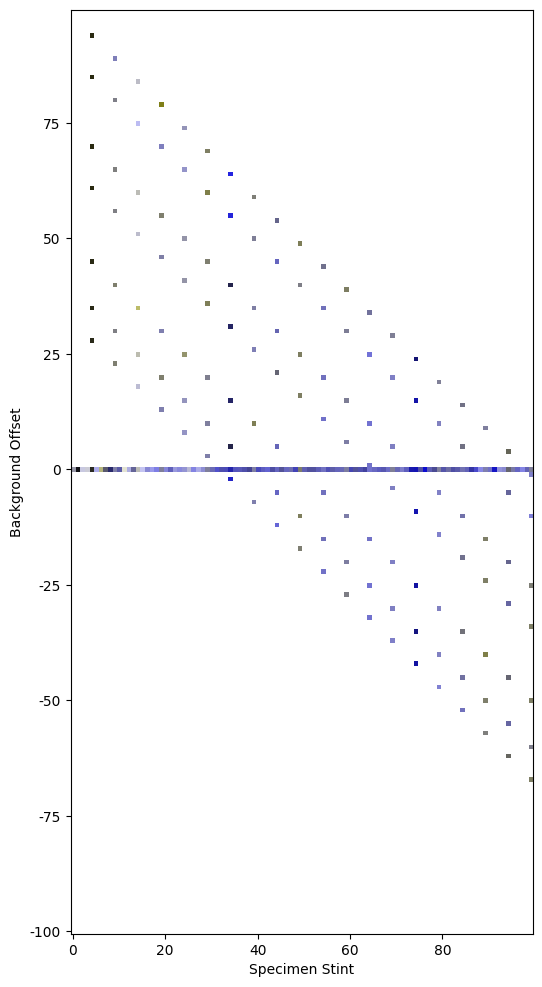

teeplots/2025-11-25-external-timeshift/palette=2+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=2+slice=sub+type=band+viz=imshow+ext=.png


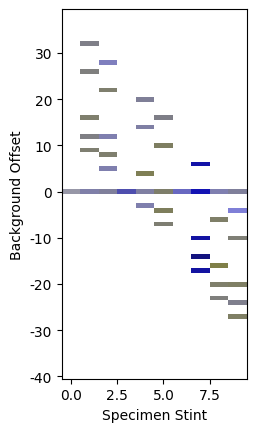

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+type=legendsquare+viz=imshow+ext=.png


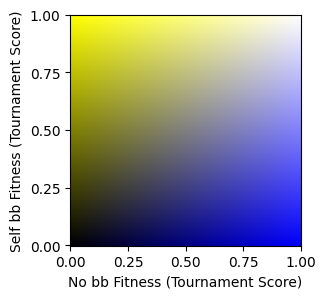

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+type=legendband+viz=imshow+ext=.png


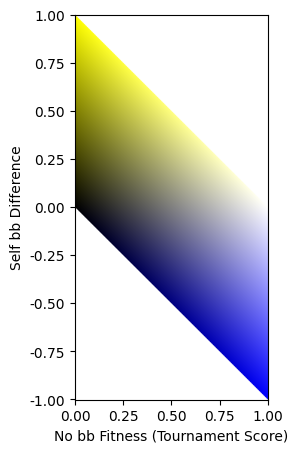

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+slice=all+type=square+viz=imshow+ext=.png


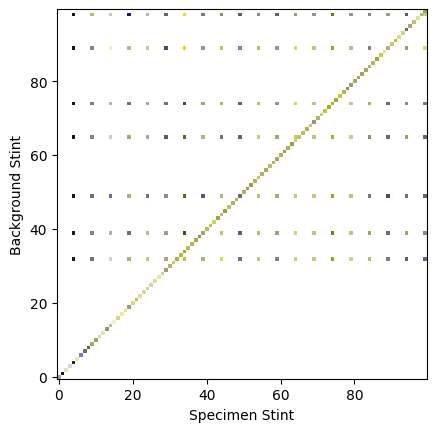

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+slice=sub+type=square+viz=imshow+ext=.png


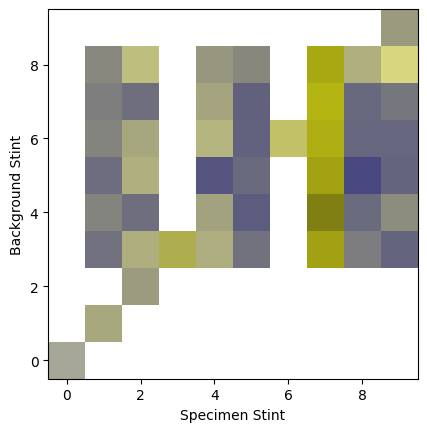

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+slice=all+type=band+viz=imshow+ext=.png


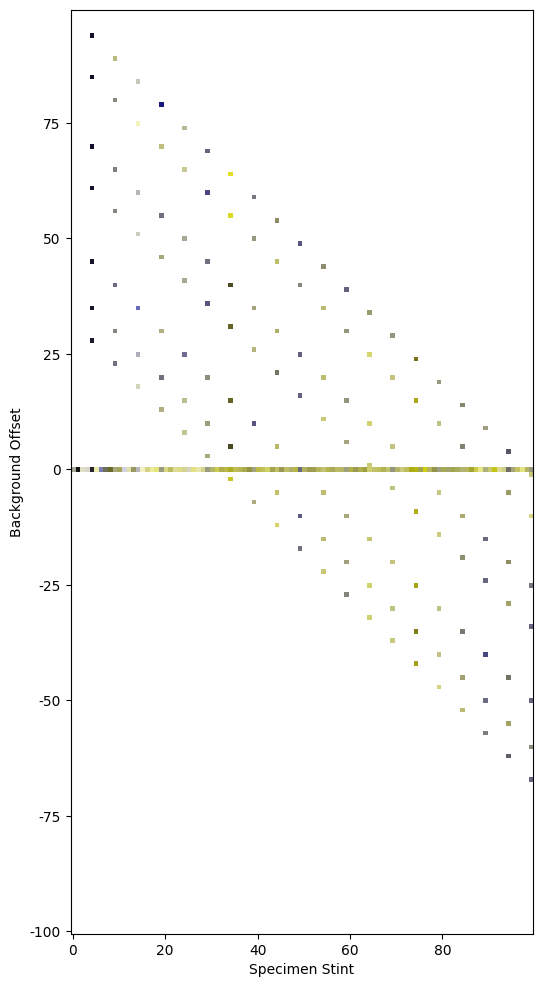

teeplots/2025-11-25-external-timeshift/palette=0~1+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=0~1+slice=sub+type=band+viz=imshow+ext=.png


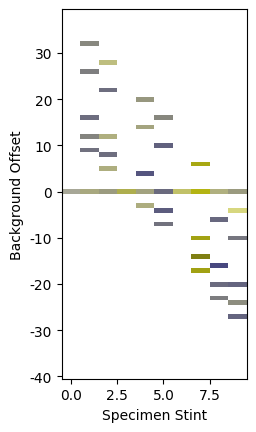

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+type=legendsquare+viz=imshow+ext=.png


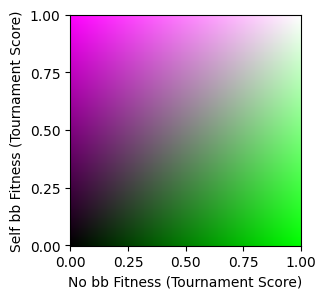

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+type=legendband+viz=imshow+ext=.png


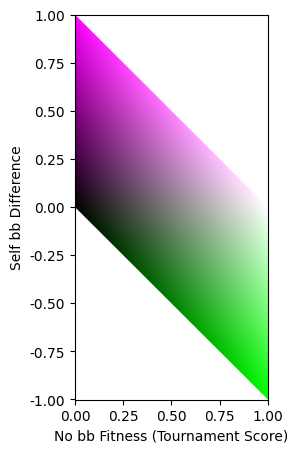

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+slice=all+type=square+viz=imshow+ext=.png


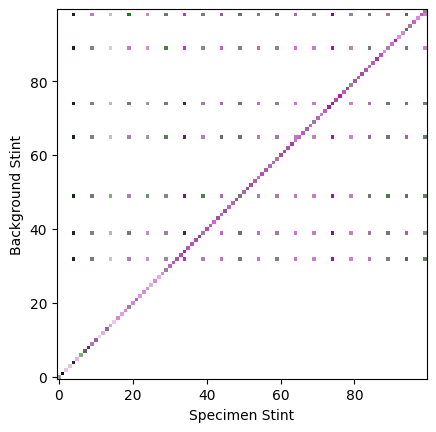

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+slice=sub+type=square+viz=imshow+ext=.png


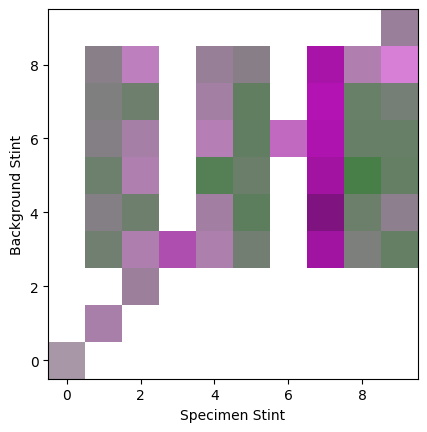

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+slice=all+type=band+viz=imshow+ext=.png


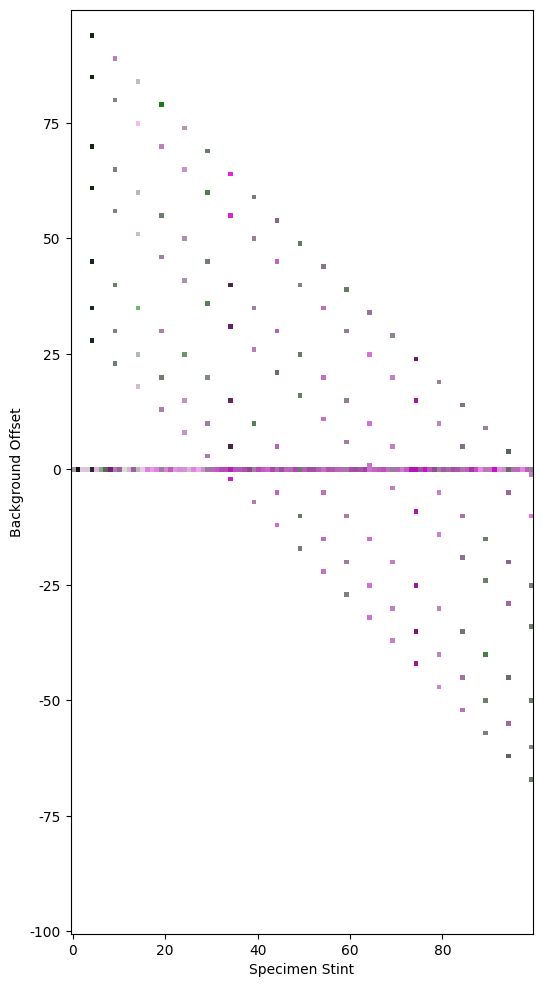

teeplots/2025-11-25-external-timeshift/palette=0~2+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=0~2+slice=sub+type=band+viz=imshow+ext=.png


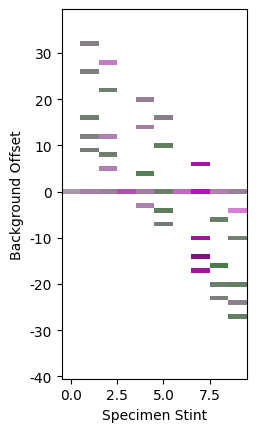

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+type=legendsquare+viz=imshow+ext=.png


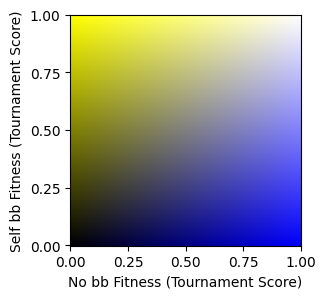

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+type=legendband+viz=imshow+ext=.png


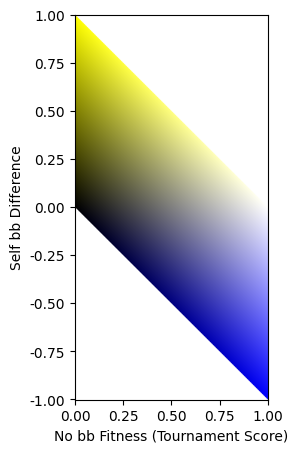

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+slice=all+type=square+viz=imshow+ext=.png


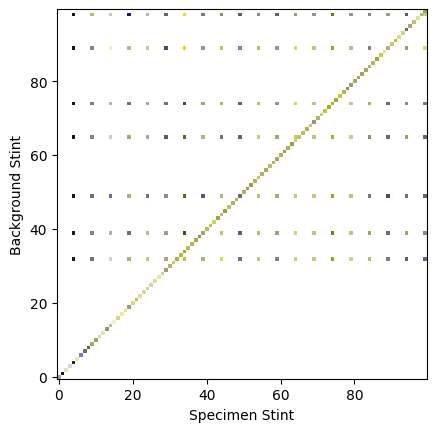

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+slice=sub+type=square+viz=imshow+ext=.png


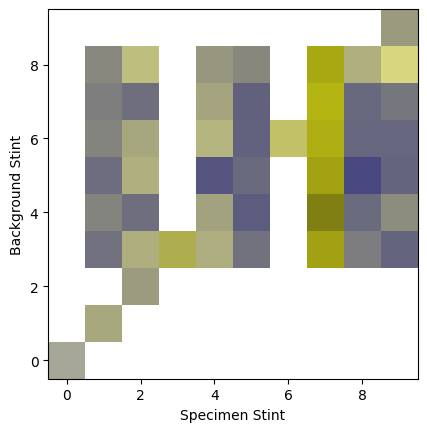

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+slice=all+type=band+viz=imshow+ext=.png


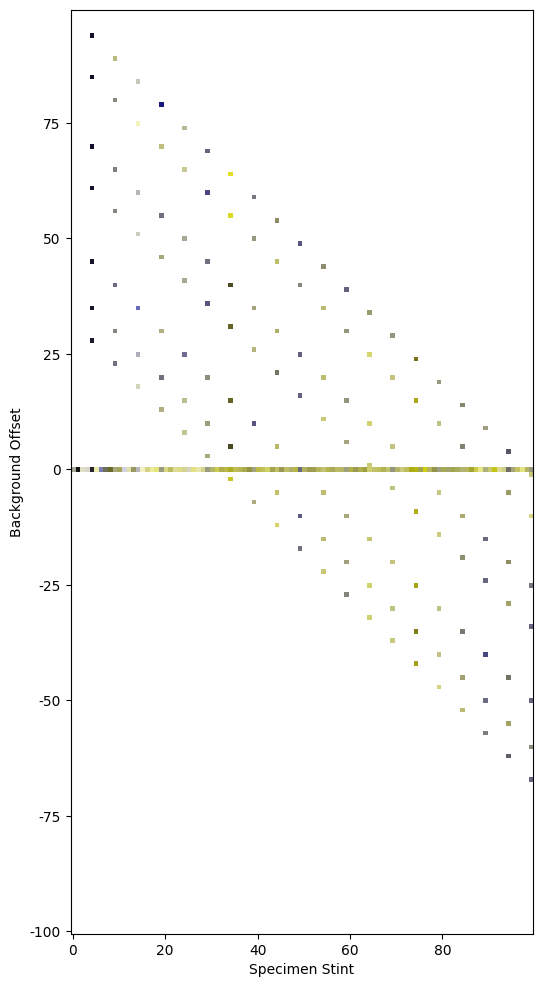

teeplots/2025-11-25-external-timeshift/palette=1~0+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=1~0+slice=sub+type=band+viz=imshow+ext=.png


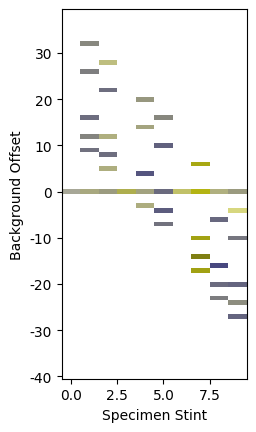

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+type=legendsquare+viz=imshow+ext=.png


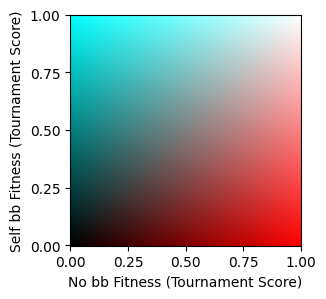

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+type=legendband+viz=imshow+ext=.png


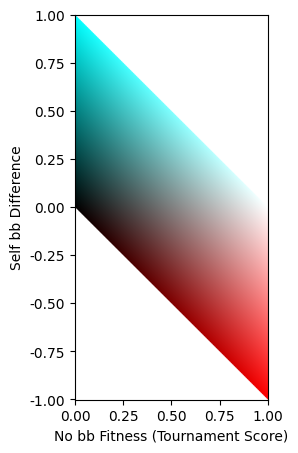

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+slice=all+type=square+viz=imshow+ext=.png


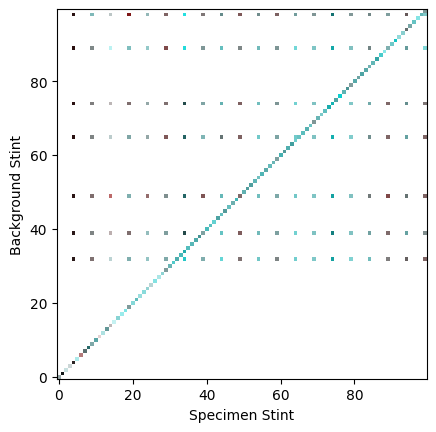

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+slice=sub+type=square+viz=imshow+ext=.png


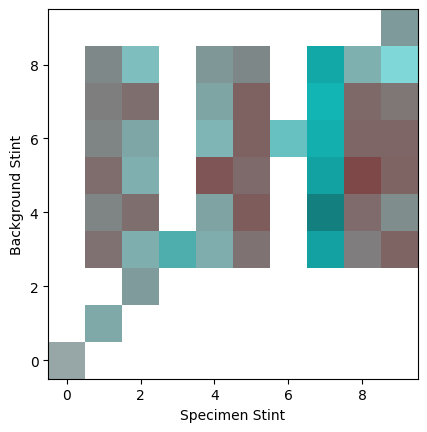

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+slice=all+type=band+viz=imshow+ext=.png


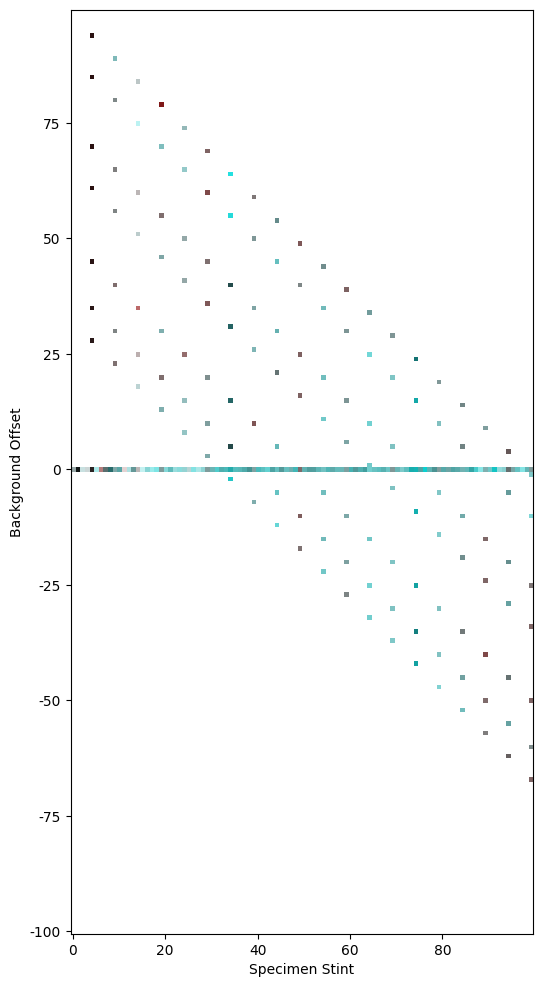

teeplots/2025-11-25-external-timeshift/palette=1~2+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=1~2+slice=sub+type=band+viz=imshow+ext=.png


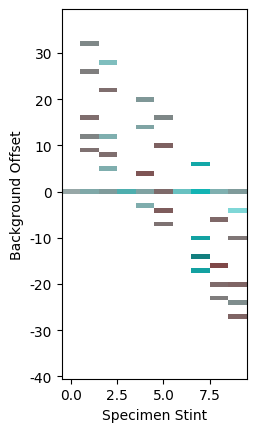

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+type=legendsquare+viz=imshow+ext=.png


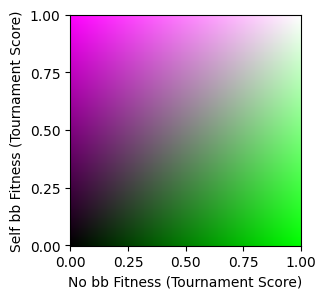

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+type=legendband+viz=imshow+ext=.png


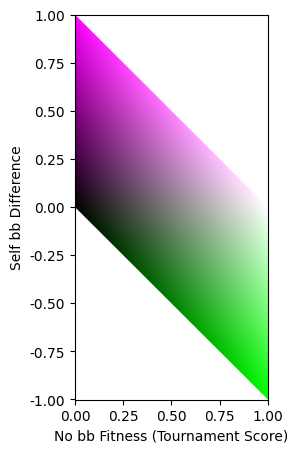

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+slice=all+type=square+viz=imshow+ext=.png


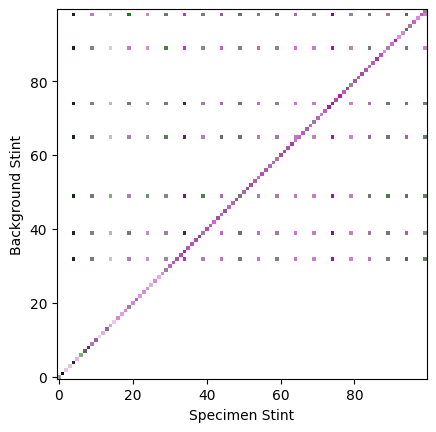

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+slice=sub+type=square+viz=imshow+ext=.png


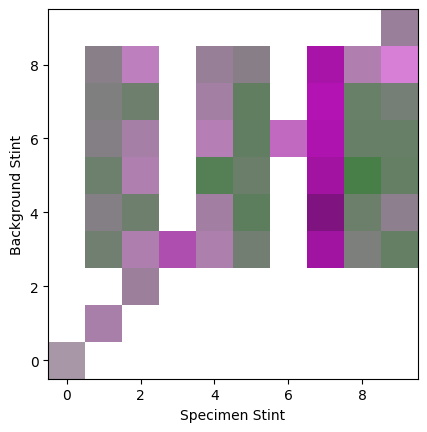

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+slice=all+type=band+viz=imshow+ext=.png


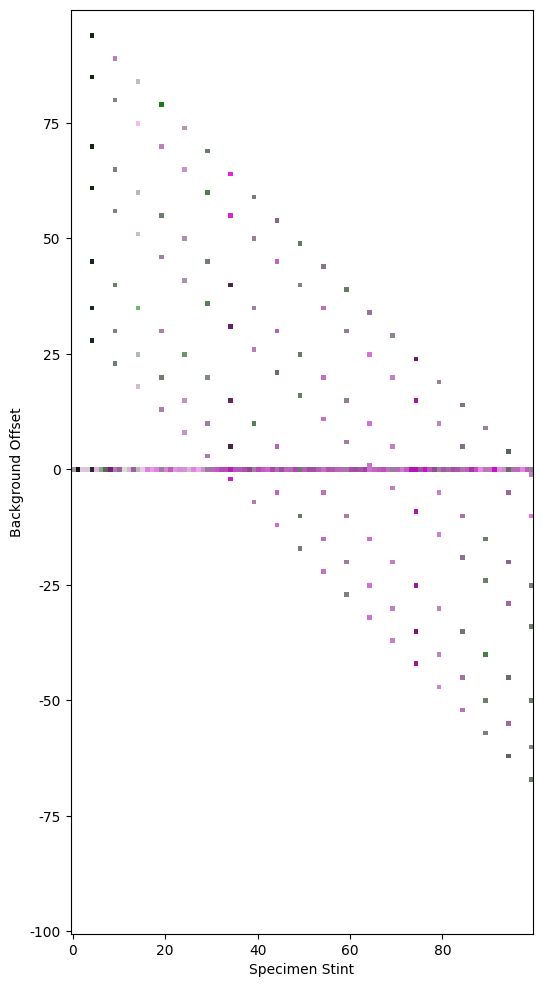

teeplots/2025-11-25-external-timeshift/palette=2~0+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=2~0+slice=sub+type=band+viz=imshow+ext=.png


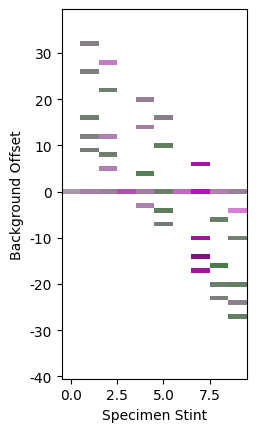

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+type=legendsquare+viz=imshow+ext=.png


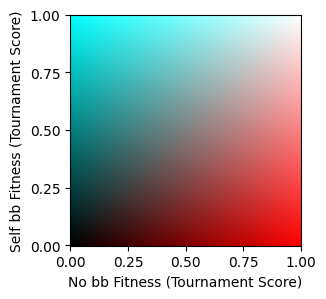

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+type=legendband+viz=imshow+ext=.png


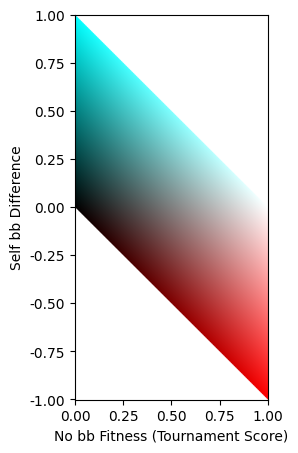

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+slice=all+type=square+viz=imshow+ext=.png


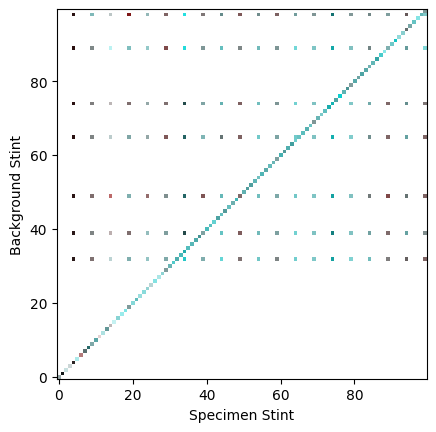

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+slice=sub+type=square+viz=imshow+ext=.png


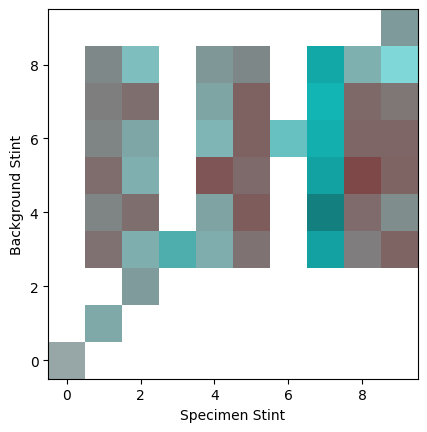

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+slice=all+type=band+viz=imshow+ext=.png


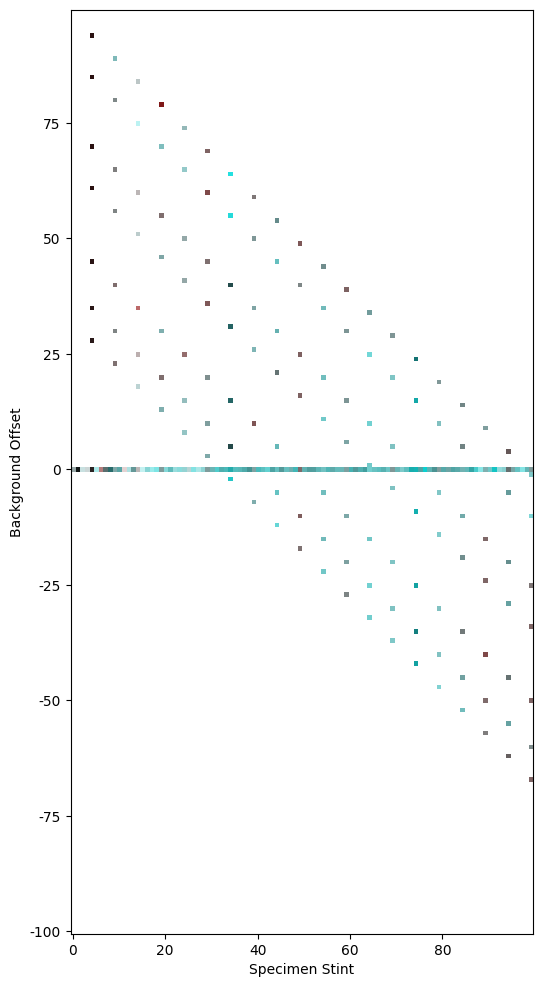

teeplots/2025-11-25-external-timeshift/palette=2~1+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=2~1+slice=sub+type=band+viz=imshow+ext=.png


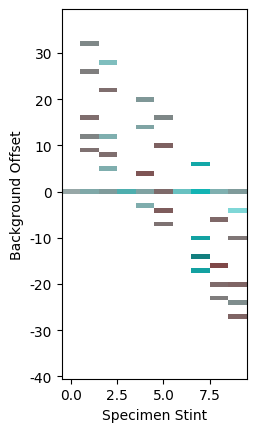

In [10]:
dfx = df.loc[
    (df["Root ID"] == 0),
    ["Competition Stint", "Focal Prevalence", "kind"]
].groupby(["Competition Stint", "kind"]).mean()
display(dfx)

bb_matrix = np.full((100, 100), np.nan)
for stint in range(1, 101):
    bb_matrix[stint - 1, stint - 1] = dfx.loc[
        (stint, "selfbb")
    ].item()

for comp in 33, 40, 50, 66, 75, 90, 99:
    for stint in range(1, 101):
        try:
            bb_matrix[comp - 1, stint - 1] = dfx.loc[
                (stint, f"selfbb{comp}")
            ].item()
        except KeyError:
            pass


nobb_matrix = np.array(
    [
        [
            dfx.loc[(stint, "nobb")].item()
            for stint in range(1, 101)
        ]
        for __ in range(1, 101)
    ],
)

def imshow(data, **kwargs):
    # force NaN handling, because some render backends show black vs white
    nan = 1 if np.issubdtype(data.dtype, np.integer) else 1.0
    data = data.copy()
    mask = np.isnan(data).any(axis=-1)
    data[mask] = np.nan
    return plt.imshow(
        np.nan_to_num(data, nan=nan),
        **kwargs,
    )

for rgb_bb in it.chain(
    it.permutations(range(3), r=1),
    it.permutations(range(3), r=2),
):
    palette = "~".join(map(str, rgb_bb))

    legend_matrix_nobb, legend_matrix_bb = np.meshgrid(
        np.linspace(0, 1, 256),
        np.linspace(0, 1, 256),
    )
    legend_rgb_matrix = np.zeros((256, 256, 3), dtype=float)
    legend_rgb_matrix[:, :, 0], legend_rgb_matrix[:, :, 1], legend_rgb_matrix[:, :, 2] = (
        legend_matrix_nobb, legend_matrix_nobb, legend_matrix_nobb
    )
    for v in rgb_bb:
        legend_rgb_matrix[:, :, v] = legend_matrix_bb

    with tp.teed(
        imshow,
        legend_rgb_matrix,
        aspect="equal",
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={"type": "legendsquare", "palette": palette},
    ) as aximg:
        ax = aximg.figure.gca()
        aximg.figure.set_size_inches(3, 3)
        ax.set_xlabel("No bb Fitness (Tournament Score)")
        ax.set_ylabel("Self bb Fitness (Tournament Score)")
        ax.set_xticks([0, 64, 128, 192, 256])
        ax.set_yticks([0, 64, 128, 192, 256])
        ax.yaxis.set_major_formatter(
            mpl_ticker.FuncFormatter(
                lambda val, pos: f"{val/256:.2f}",
            ),
        )
        ax.xaxis.set_major_formatter(
            mpl_ticker.FuncFormatter(
                lambda val, pos: f"{val/256:.2f}",
            ),
        )
        ax.invert_yaxis()

    legend_reshaped = np.full((512, 256, 3), np.nan)
    for i, j in it.product(range(256), range(256)):
        legend_reshaped[i + 256 - j, j, :] = legend_rgb_matrix[i, j, :]

    with tp.teed(
        imshow,
        legend_reshaped,
        aspect="equal",
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={"type": "legendband", "palette": palette},
    ) as aximg:
        ax = aximg.figure.gca()
        aximg.figure.set_size_inches(3, 5)
        ax.set_xlabel("No bb Fitness (Tournament Score)")
        ax.set_ylabel("Self bb Difference")
        ax.set_xticks([0, 64, 128, 192, 256])
        ax.set_yticks([0, 64, 128, 192, 256, 320, 384, 448, 512])
        ax.xaxis.set_major_formatter(
            mpl_ticker.FuncFormatter(
                lambda val, pos: f"{val/256:.2f}",
            ),
        )
        ax.yaxis.set_major_formatter(
            mpl_ticker.FuncFormatter(
                lambda val, pos: f"{(val - 256)/256:.2f}",
            ),
        )
        ax.invert_yaxis()

    rgb_matrix = np.zeros((100, 100, 3), dtype=float)
    rgb_matrix[:, :, 0], rgb_matrix[:, :, 1], rgb_matrix[:, :, 2] = (
        nobb_matrix, nobb_matrix, nobb_matrix
    )
    for v in rgb_bb:
        rgb_matrix[:, :, v] = bb_matrix



    with tp.teed(
        imshow,
        rgb_matrix,
        aspect="equal",
        teeplot_outattrs={"type": "square", "slice": "all", "palette": palette},
        teeplot_subdir=teeplot_subdir,
    ) as aximg:
        ax = aximg.figure.gca()
        ax.set_xlabel("Specimen Stint")
        ax.set_ylabel("Background Stint")
        ax.invert_yaxis()

    subslice = np.array([1, 10, 20, 33, 40, 50, 66, 75, 90, 100]) - 1

    with tp.teed(
        imshow,
        rgb_matrix[
            subslice, :, :
        ][
            :,subslice, :
        ],
        aspect="equal",
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={"type": "square", "slice": "sub", "palette": palette},
    ) as aximg:
        ax = aximg.figure.gca()
        ax.set_xlabel("Specimen Stint")
        ax.set_ylabel("Background Stint")
        ax.invert_yaxis()

    reshaped = np.full((200, 100, 3), np.nan)
    for i, j in it.product(range(100), range(100)):
        reshaped[i + 100 - j, j, :] = rgb_matrix[i, j, :]

    assert (~np.isnan(reshaped)).sum() == (~np.isnan(rgb_matrix)).sum()

    with tp.teed(
        imshow,
        reshaped,
        aspect="equal",
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={"type": "band", "slice": "all", "palette": palette},
    ) as aximg:
        aximg.figure.set_size_inches(6, 12)
        ax = aximg.figure.gca()
        ax.set_xlabel("Specimen Stint")
        ax.set_ylabel("Background Offset")
        ax.invert_yaxis()
        ax.yaxis.set_major_formatter(
            mpl_ticker.FuncFormatter(
                lambda val, pos: f"{int(val) - 100}",
            ),
        )

    with tp.teed(
        imshow,
        reshaped[
            np.array(
                [
                    [i, i + 3, i + 5, i + 8]
                    for i in range(0, 200, 10)
                ]
            ).flatten(),
            :,
            :,
        ][
            :, subslice, :
        ],
        aspect=0.25,
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={"type": "band", "slice": "sub", "palette": palette},
    ) as aximg:
        ax = aximg.figure.gca()
        ax.set_xlabel("Specimen Stint")
        ax.set_ylabel("Background Offset")
        ax.invert_yaxis()
        ax.yaxis.set_major_formatter(
            mpl_ticker.FuncFormatter(
                lambda val, pos: f"{int(val) - 40}",
            ),
        )


0         1.000000
2         0.247078
4         0.006954
6         0.393959
8         0.299972
            ...   
354612    0.000000
354615    0.000000
354618    0.929577
354620    0.147200
354623    1.000000
Name: Focal Prevalence, Length: 131222, dtype: float64

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


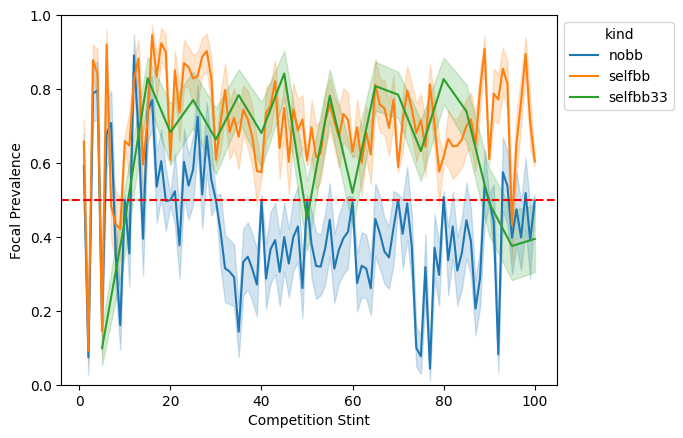

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


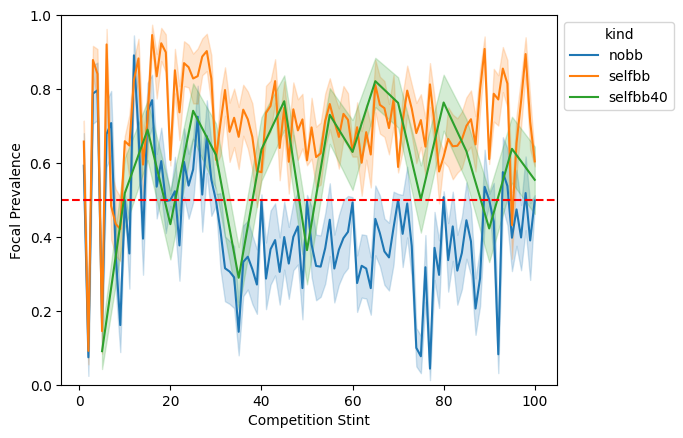

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


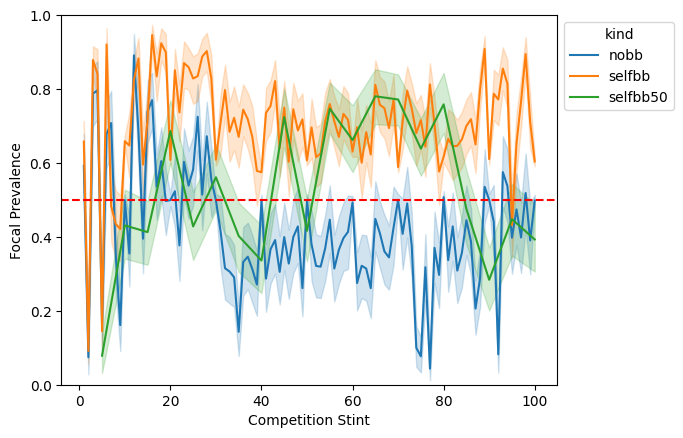

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


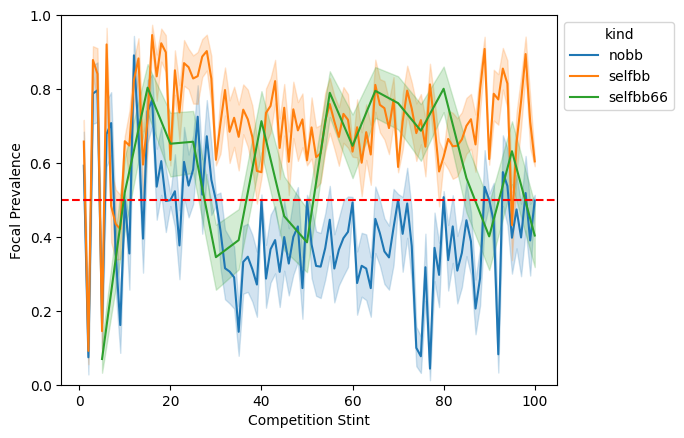

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


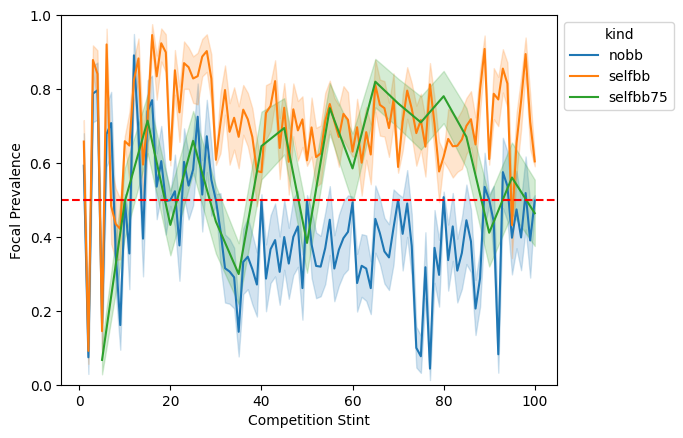

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


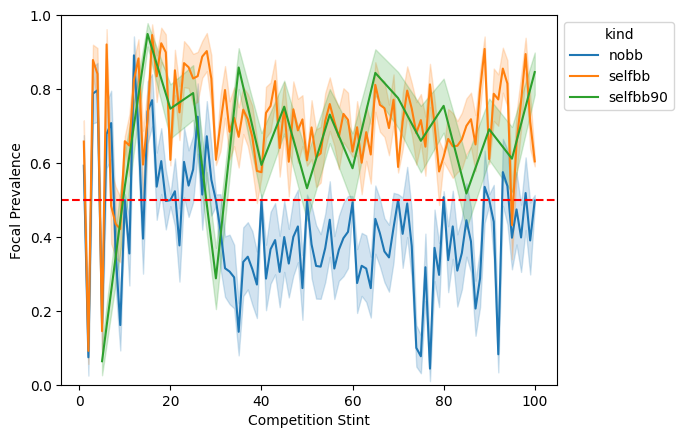

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


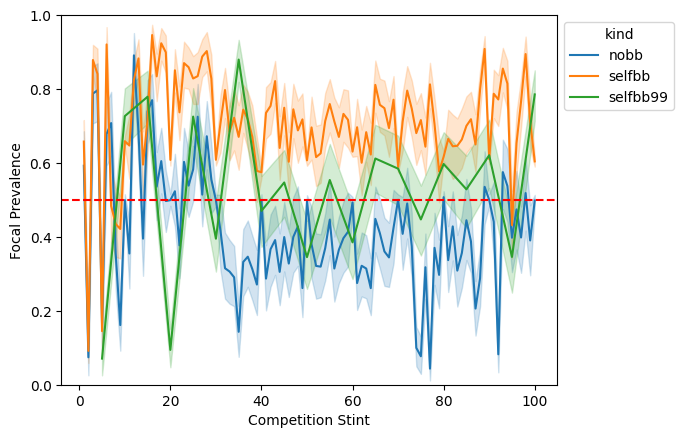

In [11]:
dfx = df.loc[
    (df["Root ID"] == 0),
    ["Competition Stint", "Focal Prevalence", "kind"]
]
display(dfx["Focal Prevalence"])

for kind in [
    "selfbb33",
    "selfbb40",
    "selfbb50",
    "selfbb66",
    "selfbb75",
    "selfbb90",
    "selfbb99",
]:
    with tp.teed(
        sns.lineplot,
        data=dfx[
            dfx["kind"].isin(["nobb", kind, "selfbb"])
        ],
        x="Competition Stint",
        y="Focal Prevalence",
        hue="kind",
        teeplot_subdir=teeplot_subdir,
    ) as ax:
        sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

        plt.axhline(y=0.5, color='r', linestyle='--')
        plt.ylim(0, 1)
